# Model Results Visualisation

This notebook creates static, report-ready visualisations for the prediction models already present in the repository.

Current scope:

- LSTM results loaded from `reports/trained_ltsm/`
- PatchTST metrics parsed from notebook outputs
- model artifact availability audit for logistic and XGBoost notebooks

In [2]:
from pathlib import Path
import json
import re

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (14, 7)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [3]:
def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() and (candidate / "src").exists() and (candidate / "reports").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root from the current working directory.")


REPO_ROOT = find_repo_root(Path.cwd())
LSTM_DIR = REPO_ROOT / "reports" / "trained_ltsm"
PATCHTST_NOTEBOOK = REPO_ROOT / "notebooks" / "05_prediction" / "patchtst.ipynb"
LOGISTIC_DIR = REPO_ROOT / "notebooks" / "05_prediction" / "logistic"
OUTPUT_DIR = REPO_ROOT / "reports" / "figures" / "model_results_visualisation"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## Helper Functions

In [4]:
def save_current_figure(name: str) -> None:
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{name}.png", dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()


def load_lstm_results() -> tuple[pd.DataFrame, pd.DataFrame]:
    test_frames = []
    cv_frames = []

    for lag in [1, 5, 30]:
        test_path = LSTM_DIR / f"results_lag_{lag}" / "test_metrics.csv"
        cv_path = LSTM_DIR / f"results_lag_{lag}" / "cv_summary.csv"

        test_df = pd.read_csv(test_path, index_col=0)
        test_df["lag"] = lag
        test_frames.append(test_df.reset_index(names="split"))

        cv_df = pd.read_csv(cv_path, index_col=0)
        cv_df["lag"] = lag
        cv_frames.append(cv_df.reset_index(names="fold"))

    test_metrics = pd.concat(test_frames, ignore_index=True)
    cv_metrics = pd.concat(cv_frames, ignore_index=True)
    return test_metrics, cv_metrics


def extract_patchtst_metrics(path: Path) -> pd.DataFrame:
    notebook = json.loads(path.read_text())
    combined_text = []

    for cell in notebook.get("cells", []):
        for output in cell.get("outputs", []):
            text = output.get("text", [])
            if isinstance(text, list):
                combined_text.append("".join(text))
            elif isinstance(text, str):
                combined_text.append(text)

    blob = "\n".join(combined_text)
    patterns = {
        "accuracy": r"Accuracy:\s*([0-9.]+)",
        "f1": r"F1-score:\s*([0-9.]+)",
        "precision": r"Precision:\s*([0-9.]+)",
        "recall": r"Recall:\s*([0-9.]+)",
        "roc_auc": r"ROC-AUC:\s*([0-9.]+)",
    }

    metrics = {}
    for name, pattern in patterns.items():
        match = re.search(pattern, blob)
        metrics[name] = float(match.group(1)) if match else None

    return pd.DataFrame([metrics], index=["PatchTST"])


def plot_image_grid(image_paths: list[Path], titles: list[str], figure_name: str, suptitle: str, ncols: int = 3) -> None:
    n_images = len(image_paths)
    nrows = (n_images + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
    axes = pd.Series(axes.flatten() if hasattr(axes, "flatten") else [axes])

    for ax, image_path, title in zip(axes, image_paths, titles):
        ax.imshow(mpimg.imread(image_path))
        ax.set_title(title)
        ax.axis("off")

    for ax in axes[len(image_paths):]:
        ax.axis("off")

    fig.suptitle(suptitle, y=1.02, fontsize=18)
    save_current_figure(figure_name)


## Artifact Availability Audit

In [5]:
availability = pd.DataFrame([
    {
        "model": "LSTM",
        "structured_metrics": (LSTM_DIR / "results_lag_1" / "test_metrics.csv").exists(),
        "saved_figures": (LSTM_DIR / "results_lag_1" / "confusion_matrix.png").exists(),
        "source": "reports/trained_ltsm",
    },
    {
        "model": "PatchTST",
        "structured_metrics": PATCHTST_NOTEBOOK.exists(),
        "saved_figures": PATCHTST_NOTEBOOK.exists(),
        "source": "patchtst notebook outputs",
    },
    {
        "model": "Logistic",
        "structured_metrics": False,
        "saved_figures": False,
        "source": "notebooks/05_prediction/logistic",
    },
    {
        "model": "XGBoost",
        "structured_metrics": False,
        "saved_figures": False,
        "source": "mixed into logistic notebooks; no exported artifacts yet",
    },
])

availability

,model,structured_metrics,saved_figures,source
0,LSTM,True,True,reports/trained_ltsm
1,PatchTST,True,True,patchtst notebook outputs
2,Logistic,False,False,notebooks/05_prediction/logistic
3,XGBoost,False,False,mixed into logistic notebooks; no exported art...


## LSTM Metrics by Forecast Horizon

In [6]:
lstm_test_metrics, lstm_cv_metrics = load_lstm_results()
lstm_test_metrics

,split,accuracy,roc_auc,precision,recall,lag
0,Test Set,0.596801,0.714047,0.989390,0.439858,1
1,Test Set,0.581650,0.690219,0.951157,0.436321,5
2,Test Set,0.678209,0.601289,0.770128,0.781991,30


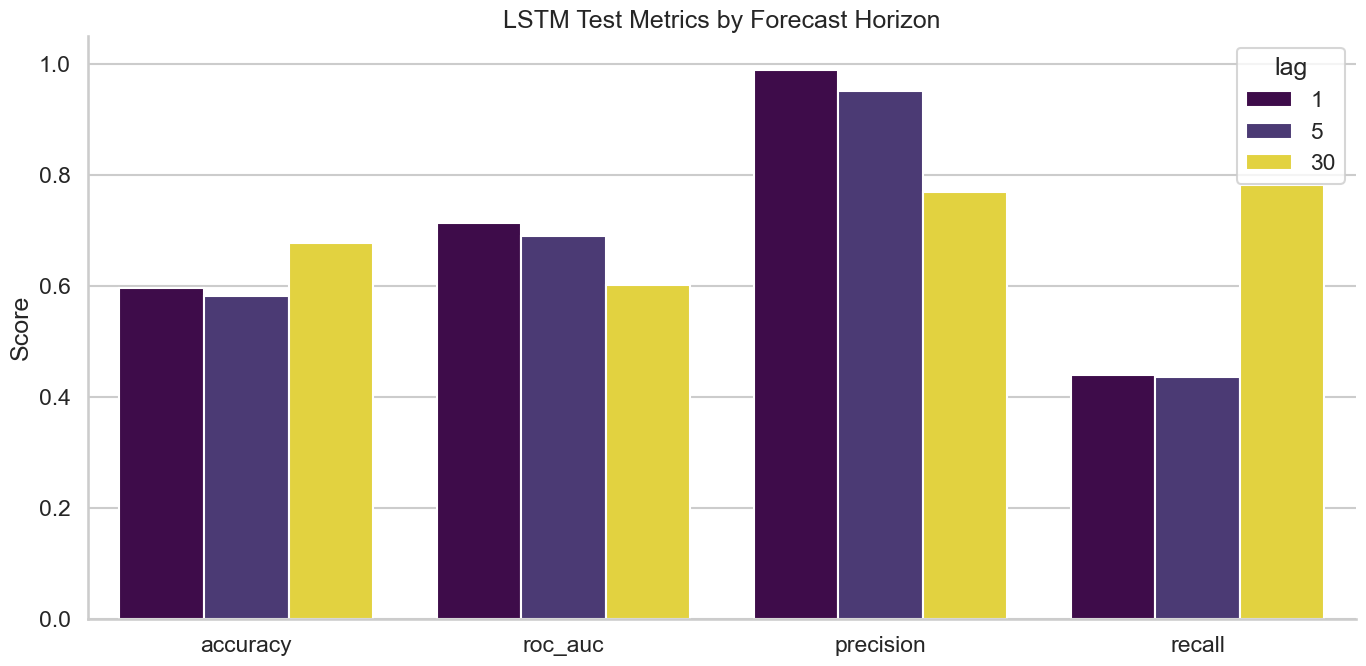

In [7]:
plot_df = lstm_test_metrics.melt(
    id_vars=["split", "lag"],
    value_vars=["accuracy", "roc_auc", "precision", "recall"],
    var_name="metric",
    value_name="value",
)

plt.figure(figsize=(14, 7))
sns.barplot(data=plot_df, x="metric", y="value", hue="lag", palette="viridis")
plt.ylim(0, 1.05)
plt.title("LSTM Test Metrics by Forecast Horizon")
plt.xlabel("")
plt.ylabel("Score")
save_current_figure("lstm_test_metrics_by_horizon")

In [8]:
cv_mean = lstm_cv_metrics[lstm_cv_metrics["fold"] == "Mean"].copy()
cv_mean

,fold,accuracy,roc_auc,precision,recall,lag
5,Mean,0.735357,0.805634,0.745346,0.858807,1
12,Mean,0.696964,0.738312,0.750677,0.733184,5
19,Mean,0.464158,0.476715,0.457325,0.542463,30


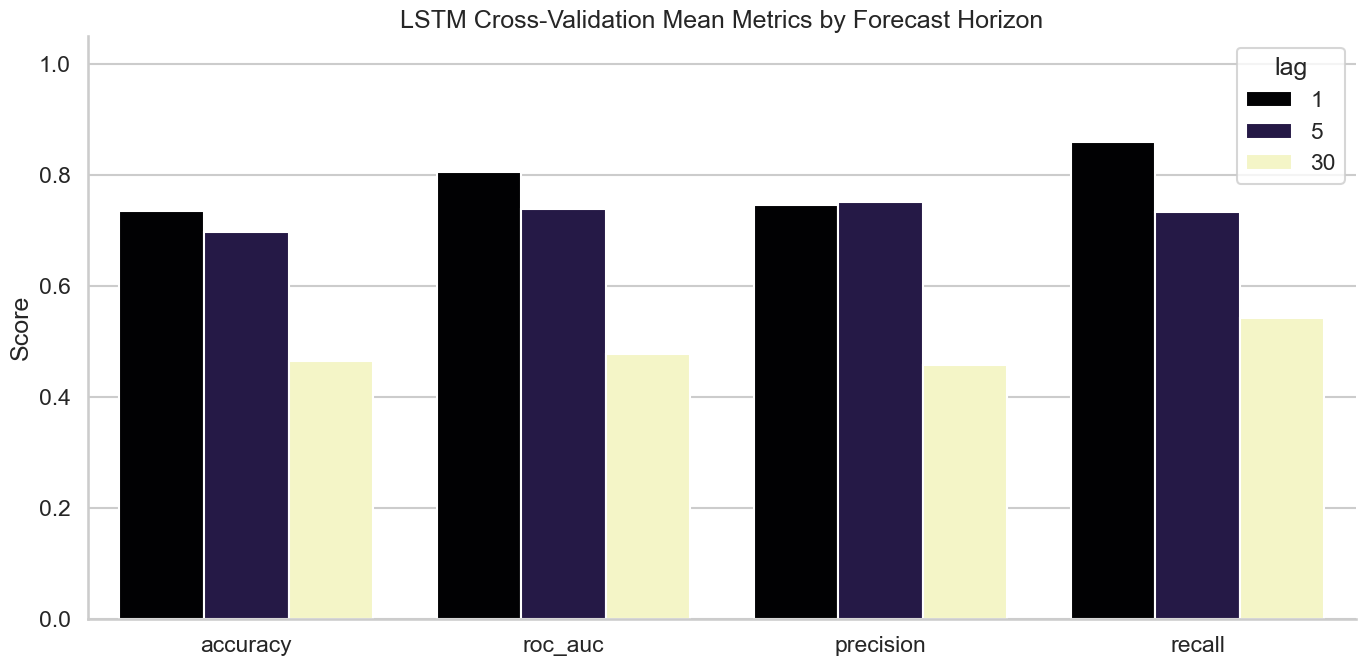

In [9]:
plot_df = cv_mean.melt(
    id_vars=["fold", "lag"],
    value_vars=["accuracy", "roc_auc", "precision", "recall"],
    var_name="metric",
    value_name="value",
)

plt.figure(figsize=(14, 7))
sns.barplot(data=plot_df, x="metric", y="value", hue="lag", palette="magma")
plt.ylim(0, 1.05)
plt.title("LSTM Cross-Validation Mean Metrics by Forecast Horizon")
plt.xlabel("")
plt.ylabel("Score")
save_current_figure("lstm_cv_mean_metrics_by_horizon")

## LSTM Saved Figures

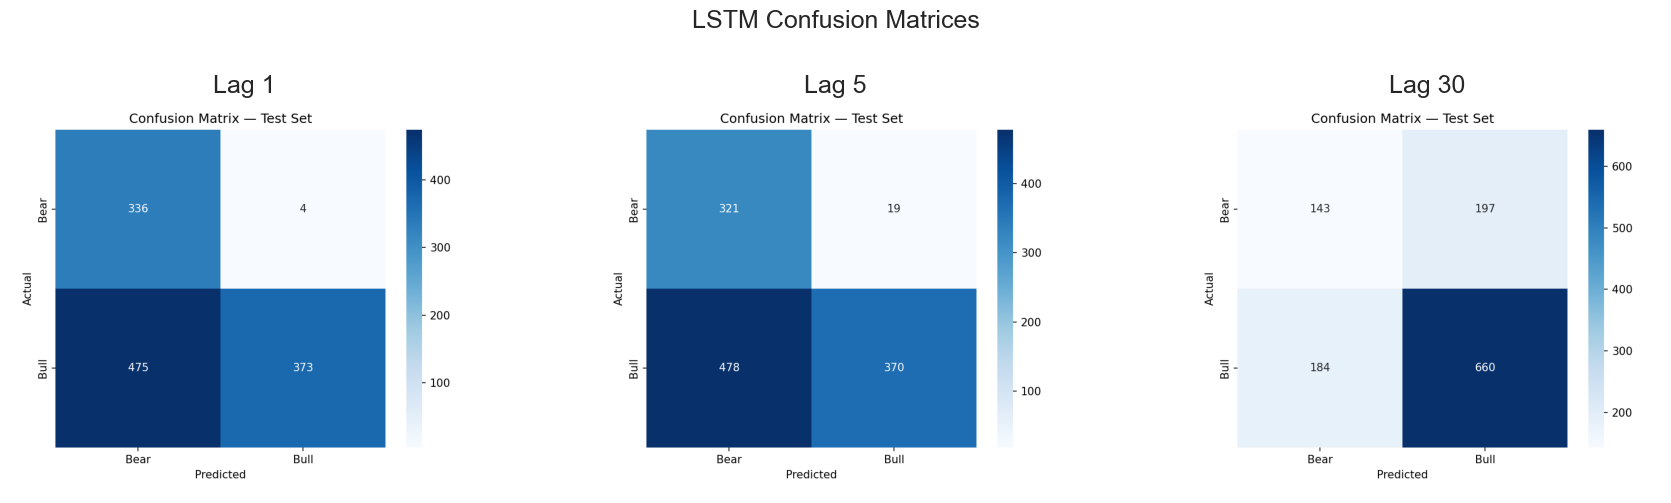

In [10]:
confusion_paths = [LSTM_DIR / f"results_lag_{lag}" / "confusion_matrix.png" for lag in [1, 5, 30]]
plot_image_grid(
    confusion_paths,
    ["Lag 1", "Lag 5", "Lag 30"],
    "lstm_confusion_matrices",
    "LSTM Confusion Matrices",
)


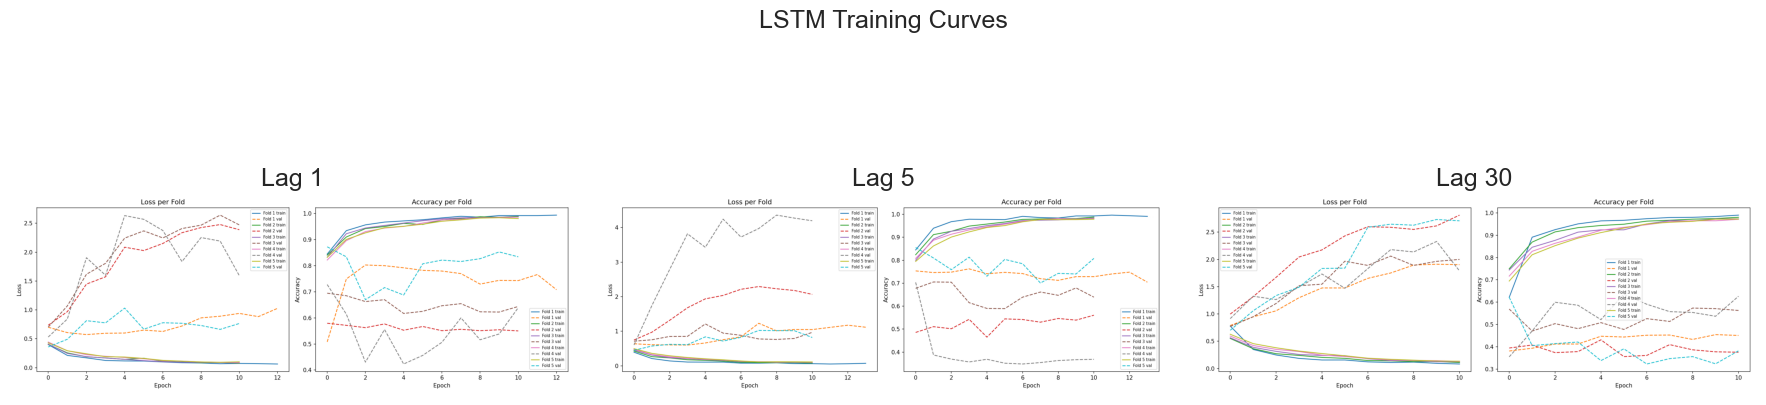

In [11]:
curve_paths = [LSTM_DIR / f"results_lag_{lag}" / "training_curves.png" for lag in [1, 5, 30]]
plot_image_grid(
    curve_paths,
    ["Lag 1", "Lag 5", "Lag 30"],
    "lstm_training_curves",
    "LSTM Training Curves",
)


## PatchTST Notebook Metrics

In [12]:
patchtst_metrics = extract_patchtst_metrics(PATCHTST_NOTEBOOK)
patchtst_metrics

,accuracy,f1,precision,recall,roc_auc
PatchTST,0.676596,0.663319,0.680808,0.530709,0.763605


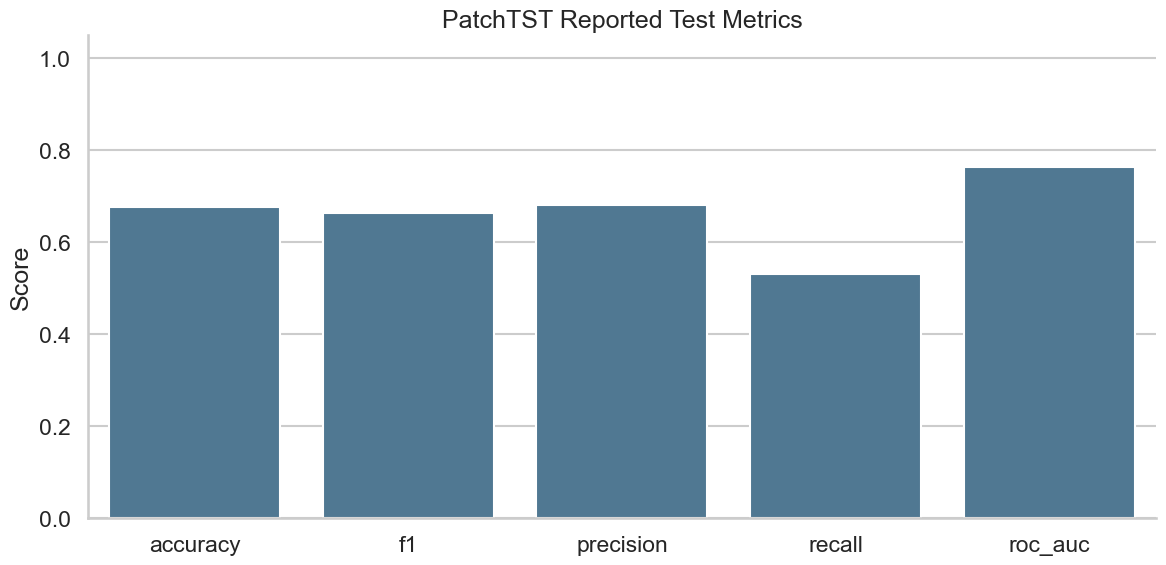

In [13]:
plot_df = patchtst_metrics.reset_index(names="model").melt(
    id_vars="model",
    value_vars=["accuracy", "f1", "precision", "recall", "roc_auc"],
    var_name="metric",
    value_name="value",
)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x="metric", y="value", color="#457b9d")
plt.ylim(0, 1.05)
plt.title("PatchTST Reported Test Metrics")
plt.xlabel("")
plt.ylabel("Score")
save_current_figure("patchtst_reported_test_metrics")

## Notes

- LSTM has the strongest reusable artifact trail right now, so it is the most complete part of this notebook.
- PatchTST metrics are parsed from notebook output text, not from exported CSVs.
- Logistic and XGBoost notebook results are not yet exported in a reusable format, so they are not included in static comparison plots yet.
- Saved figures are written to `reports/figures/model_results_visualisation/`.

Recommended next step:

- export logistic and XGBoost metrics into CSVs, then extend this notebook with model-vs-model comparison charts